## IN_DATA
- `.h5` for trajectory
- `.csv` for timestamp
- `dat_perspective`

## OUT_DATA
- `df_raw`

## PACKAGE

In [130]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.equal import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## BASH PARAMETERS

In [131]:
mouse_id = 3 #int(sys.argv[1])

In [132]:
# set directories
tag = f"mouse_{mouse_id}"
in_dir = project_dir / "results" / tag
out_dir = in_dir
#
if not os.path.exists(in_dir):
    os.makedirs(in_dir)

## LOCAL PARAMETERS

In [ ]:
# this remove some tracking errors
xy_removed_list = [
    # (0,0),
    # (0,1000),
    # (1000,0),
    # (1000,1000),
]

# split xy_traj to batches for fast assigning tile ids 
batchsize = 100000

## LOAD

In [134]:
# load metadata
n_sessions = n_sessions_dict[mouse_id]
sigma_smooth = sigma_smooth_dict[mouse_id]

# load perspective transform
M_dict, img_dict, xy_anchor_dict, base_key = pickle.load(open(project_dir / 'results' / "dat_perspective", "rb"))

# load tile data
df_tile = pickle.load(open(project_dir / 'results' / "df_tile", "rb"))

## RUN: generate df_raw for many days

In [135]:
# run to concate multiple sessions (13s)
df_raw = gen_df_raw_for_n_sessions(mouse_id, n_sessions, xy_removed_list, sigma_smooth, M_dict)

generating dff_raw for session 0
generating dff_raw for session 1
generating dff_raw for session 2
generating dff_raw for session 3


## RUN: assign tile ids to raw trajectory

In [136]:
## RUN (10s)
# prep
xy_all = df_raw[['xg', 'yg']].values
xy_pixel_all = df_tile[['x', 'y']].values
tile_id_all = df_tile.tile_id.values

def run_mp(xy_batch):
    tile_id_batch = [get_one_tile_id(xy, xy_pixel_all, tile_id_all) for xy in xy_batch]
    return tile_id_batch

# mp
xy_batch_list = [xy_all[i:i+batchsize] for i in range(0, len(xy_all), batchsize)]
with multiprocess.Pool() as pool:
    tile_id_batch_list = pool.map(run_mp, xy_batch_list)
tile_id_all = np.hstack(tile_id_batch_list)

# df
df_raw['tile_id'] = tile_id_all

## PICKLE

In [137]:
df_raw.to_pickle(out_dir / "df_raw")

## TEST

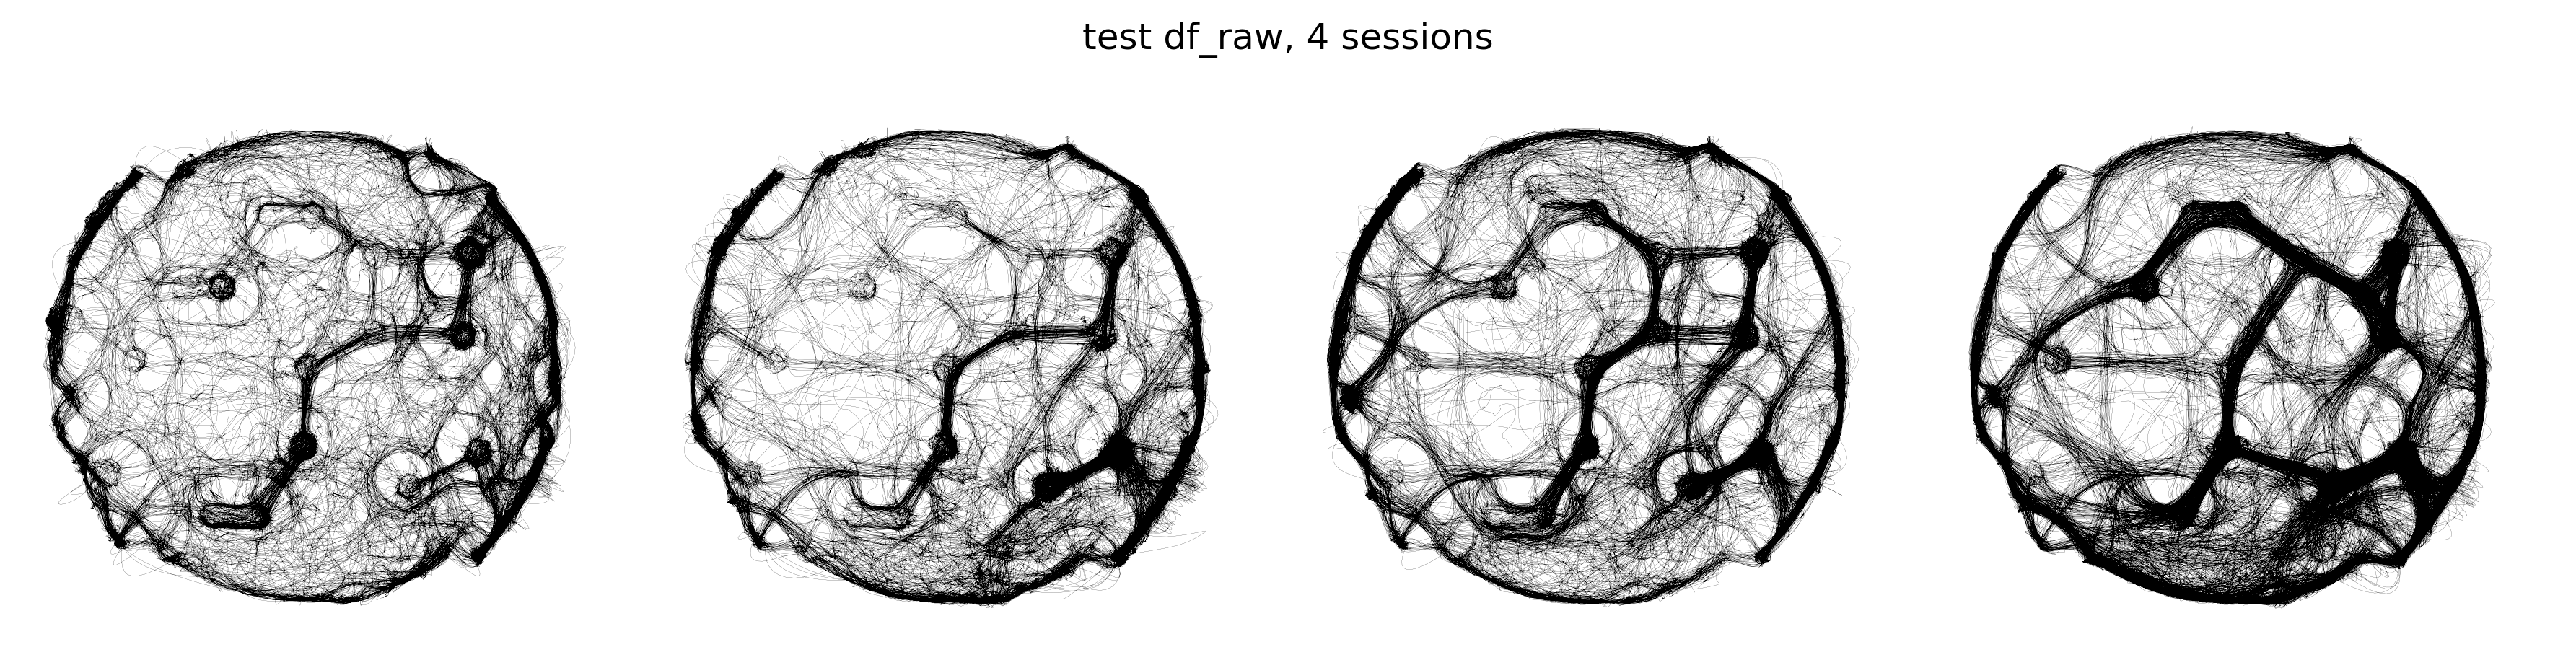

In [138]:
fig_width = 3
n_col = min(5, n_sessions)
n_row = int(np.ceil(n_sessions / n_col))
#
plt.figure(figsize=(fig_width*n_col,fig_width*n_row), dpi=300)
plt.suptitle(f"test df_raw, {n_sessions} sessions")
for session in range(n_sessions):
    img = img_dict[(mouse_id, session)]
    dff = df_raw[df_raw["session"] == session]
    plt.subplot(n_row, n_col, session+1)
    # plt.imshow(img, cmap='gray', origin='lower', alpha=.3)
    plt.plot(*dff[['xg', 'yg']].values.T, lw=.05, c='k')
    plt.axis('equal')
    plt.axis('off')
    plt.xlim(0, img.shape[1])
    # plt.ylim(0, img.shape[0])
plt.tight_layout()
plt.savefig(out_dir / "df_raw_sessions_test.png")

Text(0, 0.5, 'count')

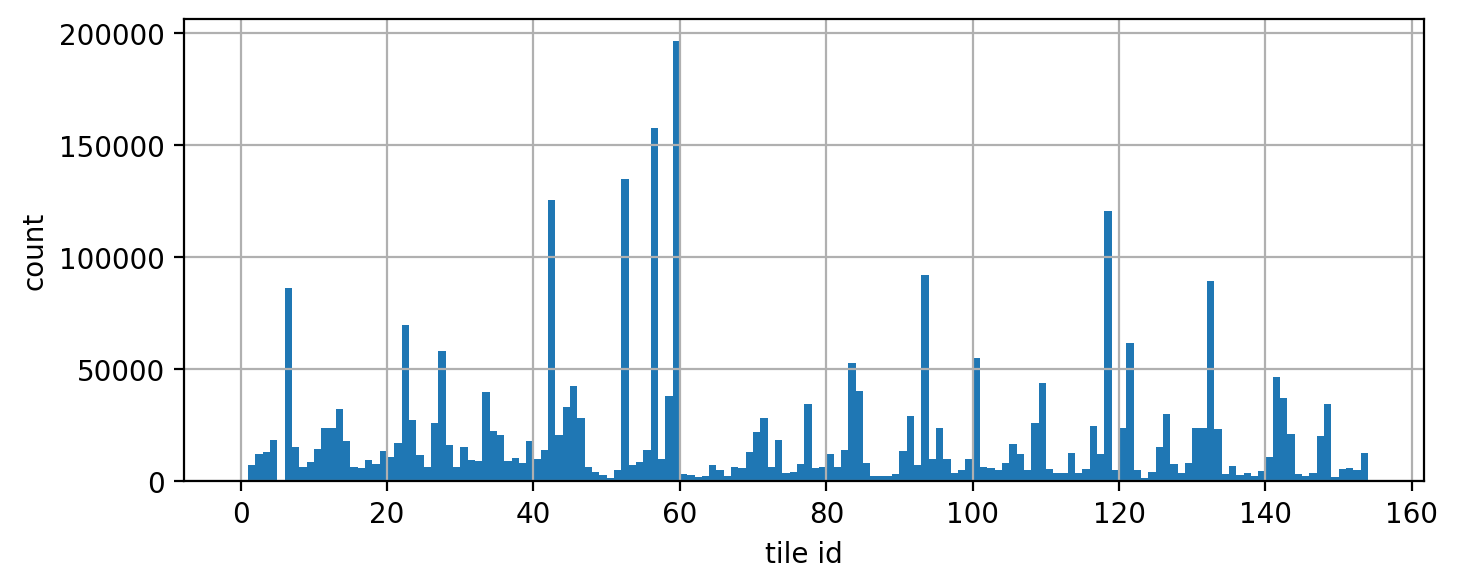

In [151]:
plt.figure(figsize=(8,3), dpi=200)
df_raw.tile_id.hist(bins=range(155))
plt.xlabel("tile id")
plt.ylabel("count")